In [5]:
%%html
<script>//Needs to be "nbsphinx" : "hidden"
MathJax.Hub.Config({
    TeX: { equationNumbers: {autoNumber: 'AMS'} }});
MathJax.Hub.Queue(
  ["resetEquationNumbers", MathJax.InputJax.TeX],
  ["PreProcess", MathJax.Hub],
  ["Reprocess", MathJax.Hub]
);
</script>

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Due to a Jupyter bug, the %matplotlib inline "magic" command needs to be in 
# its own cell. See:
# https://github.com/jupyter/notebook/issues/3385

%matplotlib inline

In [8]:
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

# Adjust default font size so that labels are readable in plots
font = {'size': 16}
matplotlib.rc('font', **font)
matplotlib.rcParams['savefig.dpi'] = 200
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = [7, 3.5]

# Model Fitting Part II

* Anscombe's Quartet
* Nonlinear models
* Fisher Information
* Bayesian Inference

The following 4 data sets, each consisting of 11 x-y pairs, are known as [Anscombe's Quartet](https://en.wikipedia.org/wiki/Anscombe's_quartet)


In [9]:
import astropy.table

a = astropy.table.Table.read('anscombe.csv',format='ascii.csv')
a

x1,y1,x2,y2,x3,y3,x4,y4
int64,float64,int64,float64,int64,float64,int64,float64
10,8.04,10,9.14,10,7.46,8,6.58
8,6.95,8,8.14,8,6.77,8,5.76
13,7.58,13,8.74,13,12.74,8,7.71
9,8.81,9,8.77,9,7.11,8,8.84
11,8.33,11,9.26,11,7.81,8,8.47
14,9.96,14,8.1,14,8.84,8,7.04
6,7.24,6,6.13,6,6.08,8,5.25
4,4.26,4,3.1,4,5.39,19,12.5
12,10.84,12,9.13,12,8.15,8,5.56


In [10]:
def print_summary_stats(x,y):

    n = len(x)
    x_mean = np.mean(x) 
    y_mean = np.mean(y) 
  
    Sxy = np.sum(x*y)- n*x_mean*y_mean 
    Sxx = np.sum(x*x)-n*x_mean*x_mean 
  
    b1 = Sxy/Sxx 
    b0 = y_mean-b1*x_mean 
    
    print('mean  of x:',x_mean)
    print('mean  of y:',y_mean)
    print('s dev of x:',np.std(x))
    print('s dev of y:',np.std(y))
    print('slope     :',b1)
    print('intercept :',b0)

In [11]:
print('Set 1')
print_summary_stats(a['x1'],a['y1'])
print('Set 2')
print_summary_stats(a['x2'],a['y2'])
print('Set 3')
print_summary_stats(a['x3'],a['y3'])
print('Set 4')
print_summary_stats(a['x4'],a['y4'])

Set 1
mean  of x: 9.0
mean  of y: 7.500909090909093
s dev of x: 3.1622776601683795
s dev of y: 1.937024215108669
slope     : 0.5000909090909079
intercept : 3.000090909090922
Set 2
mean  of x: 9.0
mean  of y: 7.50090909090909
s dev of x: 3.1622776601683795
s dev of y: 1.93710869148962
slope     : 0.500000000000001
intercept : 3.000909090909081
Set 3
mean  of x: 9.0
mean  of y: 7.5
s dev of x: 3.1622776601683795
s dev of y: 1.9359329439927313
slope     : 0.49972727272727197
intercept : 3.002454545454552
Set 4
mean  of x: 9.0
mean  of y: 7.500909090909091
s dev of x: 3.1622776601683795
s dev of y: 1.9360806451340837
slope     : 0.49990909090909097
intercept : 3.0017272727272726


They have the same means, variances (for both $x$ and $y$), correlation coefficients, linear regression slopes.

Anscombe thought traditional statistical schooling under appreciated the role that graphs play in enhancing the understanding of data. He believed three ideas permeated academia:

1. Numerical calculations are exact, but graphs are rough.

2. For any particular kind of data there is just one set of calculations constituting a correct statistical analysis.

3. Performing intricate calculations is virtuous, whereas actually looking at the data is cheating.


In [12]:
def plot_one(x,y):
    slope = 0.5
    inter = 3.
    plt.xlim([3,20])
    plt.ylim([4,14])
    plt.plot(x,y,'o')
    plt.plot([3.,19.],[3.*slope+inter,20*slope+inter],'k')
    
def plot_all(a):
    plt.rc('xtick', labelsize=10) 
    plt.rc('ytick', labelsize=10) 
    plt.subplot(221)
    plot_one(a['x1'],a['y1'])
    plt.subplot(222)
    plot_one(a['x2'],a['y2'])
    plt.subplot(223)
    plot_one(a['x3'],a['y3'])
    plt.subplot(224)
    plot_one(a['x4'],a['y4'])

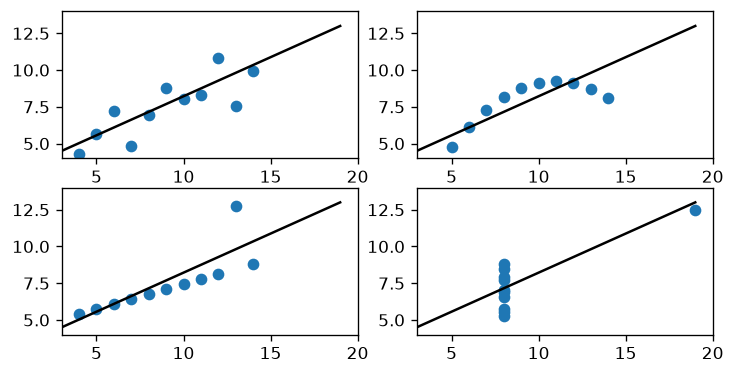

In [13]:
plot_all(a)

##  Non-linear models

Non-linear models are more complicated because setting the derivative of the log likelihood equal to zero does not usually lead to a set of equations which can be solved by matrix methods.

### Aside

Before leaping into non-linear models, note that many apparently non-linear relations can be converted into linear ones via coordinate transformations.

For example, suppose you want to fit $y = b x^a$. Taking $\ln$ of both sides gives $\ln y = a \ln x + \ln b$. <mark>Of course it may no longer be true that the uncertainties are Gaussian in $\ln y$</mark>

### Aside

In general, it is not necessary that the uncertainties in $y$ be distributed like a Gaussian.

You might have a different model for the uncertainties (especially if there are outliers). The likelihood formalism will still work, but it won't simplify to a squared-residual or $\chi^2$ "cost function".


To solve non-linear models, we still construct a log likelihood,  but to _maximise_ the likelihood, usually one has to use a numerical technique. These are  of varying degrees of sophistication, from steepest descent to Metropolis-Hastings/MCMC. 

These methods also apply to Bayesian model fitting, so we will defer discussion about how to do this maximisation until later.

## Fisher Information Matrix

The (observed) Fisher matrix can be calculated from the second derivative of the log likelihood.
$$
{\cal F_{jk}} = \left( -\left.\frac{\partial^2 \log \cal L}{\partial \theta_j \partial \theta_k} \right|_{\boldsymbol{\theta}=\hat{\boldsymbol{\theta}}} \right)
$$

A greater (negative) second derivative means the likelihood is more sharply peaked and so the constraints on the parameters are tighter.

Note that we can always do these derivatives numerically (by finite differences) if all else fails!

If the likelihood is based on a Gaussian model for the uncertainties, 
$$
{\cal F_{jk}} = \frac{1}{2} \left( \left.\frac{\partial^2 \chi^2}{\partial \theta_j \partial \theta_k} \right|_{\boldsymbol{\theta}=\hat{\boldsymbol{\theta}}} \right)
$$

Furthermore if it's a linear model then this simplifies to
$$
{\mathbf{\cal F}} = (\mathbf X^{\rm T} \mathbf{W} \mathbf X )
$$

so for this case the Fisher information is just the inverse of the covariance matrix of the parameters.

In general, the Cramer-Rao bound says the covariance matrix $\ge$ inverse of Fisher.

### Experimental design

The Fisher matrix can also be used for _experimental design_. In other words, how many measurements should we make and/or, if we have control over what those measurements are, _where_ they should be made.

The Fisher matrix is commonly used in cosmological forecasting.

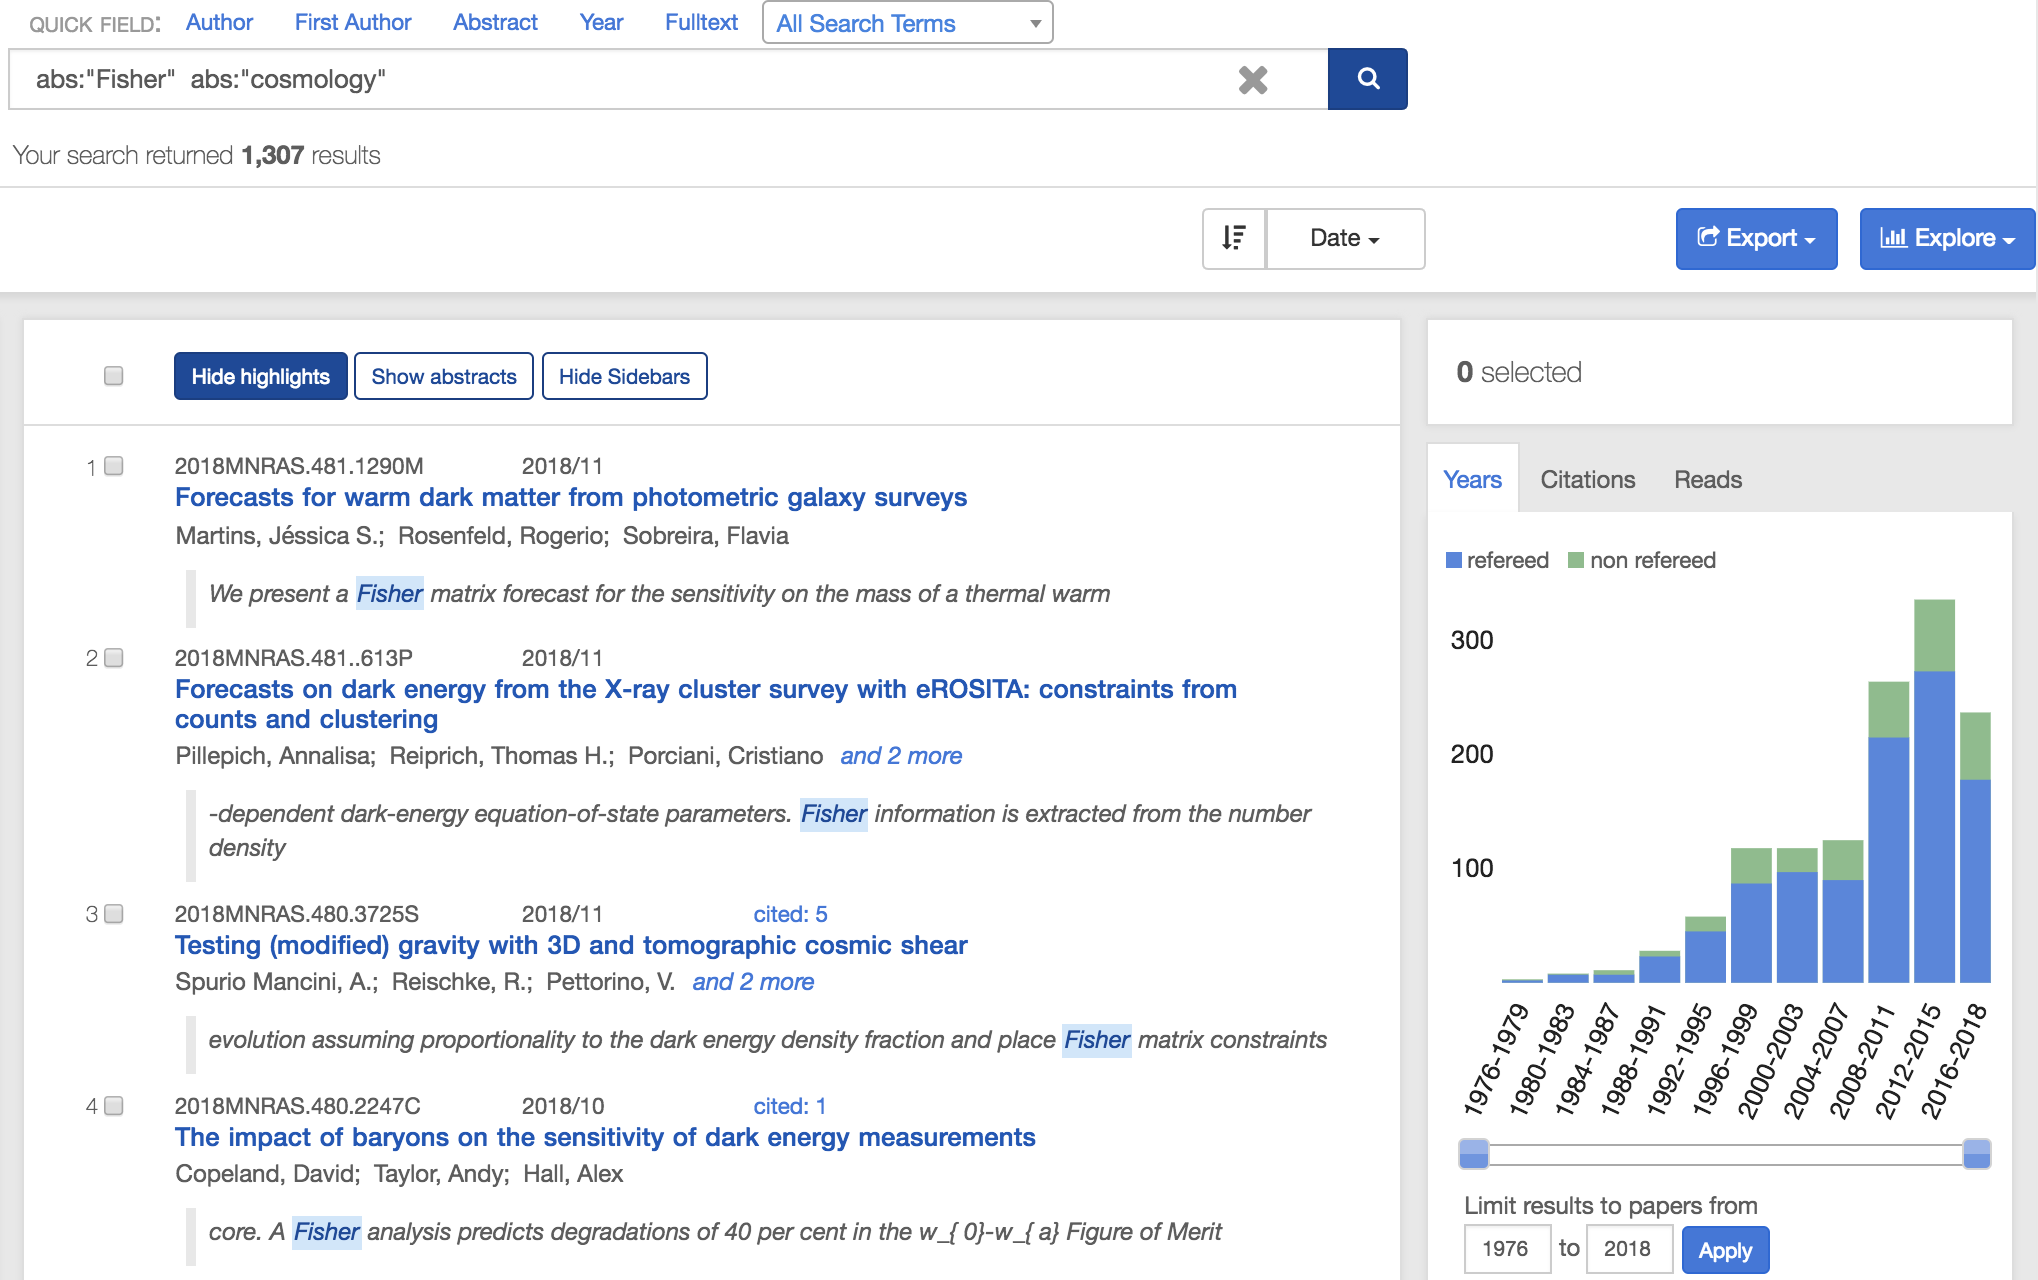

To make this more concrete (and simple), consider the example of a straight line fit with only two measurements but we have the freedom to choose at which _locations_ $x_1$ and $x_2$ the measurements of $y_1$ and $y_2$ are made. Let us suppose these measurements will have uncertainties $\sigma_1$ and $\sigma_2$.

$$
\mathbf y = \begin{bmatrix}
y_1 \\ y_2
\end{bmatrix}
\qquad
\mathbf{X}=\begin{bmatrix}
1 & x_1 \\
1 & x_2 
\end{bmatrix} ,
\qquad 
\boldsymbol \theta = 
\begin{bmatrix}
b \\ m 
\end{bmatrix},
$$


For fun, let's solve this with ``sympy``

In [15]:
from __future__ import division

from sympy import *
init_printing()

(x1, x2, s1, s2, y1, y2) = symbols('x_1 x_2 sigma_1 sigma_2 y_1 y_2')

In [16]:
# Data matrix
X = Matrix([[1, x1],[1, x2]])
X

⎡1  x₁⎤
⎢     ⎥
⎣1  x₂⎦

In [17]:
# Make the W (weight) matrix
W = Matrix([[1/s1**2, 0],[0, 1/s2**2]])
W

⎡ 1      ⎤
⎢───   0 ⎥
⎢  2     ⎥
⎢σ₁      ⎥
⎢        ⎥
⎢      1 ⎥
⎢ 0   ───⎥
⎢       2⎥
⎣     σ₂ ⎦

In [18]:
# Fisher matrix
F = X.T*W*X
F

⎡ 1     1   x₂    x₁ ⎤
⎢─── + ───  ─── + ───⎥
⎢  2     2    2     2⎥
⎢σ₂    σ₁   σ₂    σ₁ ⎥
⎢                    ⎥
⎢             2     2⎥
⎢x₂    x₁   x₂    x₁ ⎥
⎢─── + ───  ─── + ───⎥
⎢  2     2    2     2⎥
⎣σ₂    σ₁   σ₂    σ₁ ⎦

In [19]:
# Covariance matrix
Covar = F**-1
Covar

⎡   2   2     2   2        2        2    ⎤
⎢ σ₁ ⋅x₂  + σ₂ ⋅x₁     - σ₁ ⋅x₂ - σ₂ ⋅x₁ ⎥
⎢───────────────────  ───────────────────⎥
⎢  2               2    2               2⎥
⎢x₁  - 2⋅x₁⋅x₂ + x₂   x₁  - 2⋅x₁⋅x₂ + x₂ ⎥
⎢                                        ⎥
⎢     2        2             2     2     ⎥
⎢ - σ₁ ⋅x₂ - σ₂ ⋅x₁        σ₁  + σ₂      ⎥
⎢───────────────────  ───────────────────⎥
⎢  2               2    2               2⎥
⎣x₁  - 2⋅x₁⋅x₂ + x₂   x₁  - 2⋅x₁⋅x₂ + x₂ ⎦

But we can see that there is a common denominator

In [20]:
# Extract the greatest common divisor
g = gcd(tuple(Covar))
# it looks nicer as a square
g = factor(g)
g

In [21]:
# reconstruct the covariance matrix
Covar_v2 = MatMul(g,simplify(Covar/g), evaluate = False)
Covar_v2

           ⎡  2   2     2   2      2        2   ⎤
    1      ⎢σ₁ ⋅x₂  + σ₂ ⋅x₁   - σ₁ ⋅x₂ - σ₂ ⋅x₁⎥
──────────⋅⎢                                    ⎥
         2 ⎢    2        2           2     2    ⎥
(x₁ - x₂)  ⎣- σ₁ ⋅x₂ - σ₂ ⋅x₁      σ₁  + σ₂     ⎦

In [22]:
print(latex(Covar_v2)) # Sympy can convert to LaTeX

\frac{1}{\left(x_{1} - x_{2}\right)^{2}} \left[\begin{matrix}\sigma_{1}^{2} x_{2}^{2} + \sigma_{2}^{2} x_{1}^{2} & - \sigma_{1}^{2} x_{2} - \sigma_{2}^{2} x_{1}\\- \sigma_{1}^{2} x_{2} - \sigma_{2}^{2} x_{1} & \sigma_{1}^{2} + \sigma_{2}^{2}\end{matrix}\right]


$$
\frac{1}{\left(x_{1} - x_{2}\right)^{2}} \left[\begin{matrix}\sigma_{1}^{2} x_{2}^{2} + \sigma_{2}^{2} x_{1}^{2} & - \sigma_{1}^{2} x_{2} - \sigma_{2}^{2} x_{1}\\- \sigma_{1}^{2} x_{2} - \sigma_{2}^{2} x_{1} & \sigma_{1}^{2} + \sigma_{2}^{2}\end{matrix}\right]
$$

If I want to eliminate the _covariance_ between the slope and intercept, how should I choose $x_1$ and $x_2$?

(This could be a design element of your experiment or survey)

$$
\frac{1}{\left(x_{1} - x_{2}\right)^{2}} \left[\begin{matrix}\sigma_{1}^{2} x_{2}^{2} + \sigma_{2}^{2} x_{1}^{2} & - \sigma_{1}^{2} x_{2} - \sigma_{2}^{2} x_{1}\\- \sigma_{1}^{2} x_{2} - \sigma_{2}^{2} x_{1} & \sigma_{1}^{2} + \sigma_{2}^{2}\end{matrix}\right]
$$

As $x_1$ and $x_2$ become closer what happens to the uncertainties?

If $x_1 = x_2$ what does this mean? 

<b>Errors blow up, which means that you want to pick x1 and x2 further apart -> more leverage for the slope </b>

## Bayesian Model Fitting

### Bayesian Inference

Now consider that you have a dataset which might be a set or vector of numbers, the data  ${\bf D} = \{d_1, d_2 \ldots d_n\}$. You want to describe the data by some model which has a set of model parameters ${\bf M} =  \{\theta_1, \theta_2 \ldots \theta_m\}$. Your knowledge allows you to calculate the probability of the data for a given choice of model parameters: $p({\bf D}| {\bf M})$, the likelihood. 

We can find the model by using **Bayes' Rule**:

$$
p({\bf M}| {\bf D}) =  \frac{p({\bf D}| {\bf M}) \, p({\bf M})}{p({\bf D})}
$$

- $p({\bf D}| {\bf M})$ is the _likelihood_.
- $p({\bf M})$ is called the _prior_.
- $p({\bf M}| {\bf D})$ is called the _posterior_. This is what we want to maximise as a function of the model parameters ${\bf M}$.
- $p({\bf D})$ is the _model evidence_.

But we can re-write the above as:
$$
p({\bf M}| {\bf D}) =  \frac{p({\bf D}| {\bf M}) \, p({\bf M})}{\int p({\bf D}| {\bf M}) \, p({\bf M}) d{\bf M}}
$$

because we can _marginalize_ over the model $M$ by integrating.


Effectively, the difference between Bayesian inference and Maximum Likelihood is the presence of the _prior_, which depends on the model parameters.

Note that calculation of these quantities will usually involve multidimensional integrations. These are often done with Monte Carlo methods.

##### Example:

Suppose we have the following measurements of the mass of a planet, in units of Jupiter mass: $1.6\pm 1.9$, $1.2 \pm 0.9$.

A prior is that the planet's mass is $>0$.

Let us use the uncertainties package to solve for the ML solution:

In [23]:
from uncertainties import ufloat
import scipy.stats

x1 = ufloat(1.6, 1.9)
x2 = ufloat(1.2, 0.9)
w1 = (x1.s)**(-2)
w2 = (x2.s)**(-2)
wmean = (w1*x1+w2*x2)/(w1+w2)
print(wmean)

1.3+/-0.8


In [24]:
rv = scipy.stats.norm(loc=wmean.n, scale=wmean.s)
x = np.arange(-1.,4.,0.01)
# For ML 
p_ML = rv.pdf(x)

# For Bayes, we multiply by the prior (M>0) and re-normalize
denom = 1.-rv.cdf(0.) # integral of likelihood * prior
p_bayes = np.where(x>0., rv.pdf(x)/denom, 0.)
xbar = np.sum(x*p_bayes)/np.sum(p_bayes)
print("Mean of Bayesian posterior PDF is:", xbar)

Mean of Bayesian posterior PDF is: 1.372253572201872


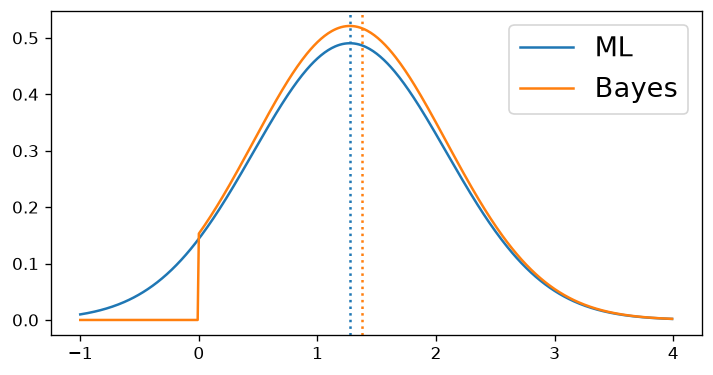

In [25]:
lml = plt.plot(x, p_ML, label='ML') # ML solution
plt.axvline(rv.mean(), ls=":", color=lml[0].get_color())

lb = plt.plot(x, p_bayes, label='Bayes')
plt.axvline(np.sum(x*p_bayes)/np.sum(p_bayes), ls=":", color=lb[0].get_color())
plt.legend();

Of course if the prior is uniform (or very slowly varying) over the range spanned by the likelihood, then there is little difference between ML and Bayesian methods. 

### Nuisance parameters


The model parameters in ${\bf M}$ are not necessarily all of physical interest. 

For example, the data may include some calibration factors (which are not known perfectly), or a background which needs to be modelled.

These become essentially free parameters of the model in addition to the more physical parameters. Moreover these extra parameters may be correlated with the physical parameters of interest.

<div>
<img src="https://atlas-public.web.cern.ch/sites/default/files/figure2.jpg" width="500"/>
</div>

The distribution of the invariant mass of the two photons in the ATLAS measurement of H→γγ using the full 2015+2016 data set. An excess is observed for a mass of ~125 GeV. To improve the visibility of the excess, events are categorized and weighted according to the sensitivity of the various categories. (Image: ATLAS Experiment/CERN from [here](https://atlas.cern/updates/physics-briefing/atlas-observes-higgs-boson-run-2-data))

These are called "nuisance parameters". What do we do with them?

_Marginalize_ them away.

In practice this means integrating over them. 

If the joint PDF is well described by a multivariate Gaussian with a covariance matrix, then things are even easier: it simply means dropping the rows and columns corresponding to the nuisance parameters.